# POSSM SBP pretraining comparison

Colab workflow for compute-matched SBP experiments. The active configuration pools Brain2Text24 `competition_train` with unlabeled Brain2Text25 `train`/`val` for Stage 1. Stage 2 always fine-tunes on Brain2Text24 and evaluates on its held-out competition test split.


In [1]:
# Definition only; expected runtime is ~0 s. It executes after setup/configuration.
_POOLED_FP16_STATS_CELL_SOURCE = r'''
# TEMPORARY ONE-TIME CELL: create the missing topology-matched B2T25 FP16
# cache, then algebraically create pooled FP16 Stage-1 stats.

import json
import os

legacy_b2t24_smoothed = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1_smoothed_sigma2p0'
legacy_b2t25_smoothed = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1_possm_b2t25_area6v_sigma2p0_v1'
pooled_legacy_stats_path = resolve_precomputed_session_stats_path(
    cache_root=legacy_b2t24_smoothed,
    signal_spec=STAGE1_SIGNAL_SPEC,
    dataset_plan=STAGE1_DATASET_PLAN,
    boundary_key_mode=BOUNDARY_KEY_MODE,
    dataset_cache_roots={'brain2text25': legacy_b2t25_smoothed},
)
pooled_fp16_stats_path = resolve_precomputed_session_stats_path(
    cache_root=DEFAULT_CACHE_ROOT_SMOOTHED,
    signal_spec=STAGE1_SIGNAL_SPEC,
    dataset_plan=STAGE1_DATASET_PLAN,
    boundary_key_mode=BOUNDARY_KEY_MODE,
    dataset_cache_roots={'brain2text25': STAGE1_B2T25_CACHE_ROOT_SMOOTHED},
)

b2t25_destination_metadata = STAGE1_B2T25_CACHE_ROOT_SMOOTHED / 'brain2text25' / 'metadata.json'
if pooled_fp16_stats_path.exists() and pooled_fp16_stats_path.with_suffix('.json').exists():
    if not b2t25_destination_metadata.exists():
        raise RuntimeError(
            f'Pooled stats exist but their B2T25 cache is missing: {STAGE1_B2T25_CACHE_ROOT_SMOOTHED}'
        )
    existing_b2t25_metadata = json.loads(b2t25_destination_metadata.read_text())
    existing_transform = existing_b2t25_metadata.get('sbp_transform_provenance') or {}
    if (
        existing_b2t25_metadata.get('sbp_storage_dtype') != 'float16'
        or float(existing_b2t25_metadata.get('sbp_clip_threshold', -1)) != 12500.0
        or existing_transform.get('source_cache_name') != legacy_b2t25_smoothed.name
    ):
        raise RuntimeError(f'Existing B2T25 FP16 cache has incompatible provenance: {b2t25_destination_metadata}')
    print('Pooled FP16 Stage-1 stats already exist:', pooled_fp16_stats_path)
else:
    if STAGE1_DATASET_PLAN.to_dict() != POSSM_B2T24_B2T25_SBP.dataset_plan.to_dict():
        raise ValueError('Temporary pooled-stats cell requires POSSM_B2T24_B2T25_SBP.')
    if not pooled_legacy_stats_path.exists():
        raise FileNotFoundError(f'Missing legacy pooled stats: {pooled_legacy_stats_path}')
    legacy_b2t25_metadata = json.loads(
        (legacy_b2t25_smoothed / 'brain2text25' / 'metadata.json').read_text()
    )
    if (
        (legacy_b2t25_metadata.get('feature_layout') or {}).get('n_sbp_features') != 128
        or (legacy_b2t25_metadata.get('area6v_migration') or {}).get('area6v_only') is not True
    ):
        raise RuntimeError('Legacy B2T25 source is not the expected 128-channel area-6v cache.')
    for required_root in (
        legacy_b2t24_smoothed, legacy_b2t25_smoothed, DEFAULT_CACHE_ROOT_SMOOTHED,
    ):
        if not required_root.is_dir():
            raise FileNotFoundError(f'Missing required cache root: {required_root}')

    converter_source = subprocess.run(
        [
            'git', '-C', str(REPO_DIR), 'show',
            '9825802:utah_ssl/scripts/clip_sbp_fp16_and_update_stats.py',
        ],
        check=True, capture_output=True, text=True,
    ).stdout
    archived_path_bootstrap = (
        "EXPERIMENTS_DIR = Path(__file__).resolve().parents[2]\n"
        "REPO_ROOT = Path(__file__).resolve().parents[5]"
    )
    if archived_path_bootstrap not in converter_source:
        raise RuntimeError('Archived converter path bootstrap was not found.')
    converter_source = converter_source.replace(
        archived_path_bootstrap,
        f"EXPERIMENTS_DIR = Path({str(EXPERIMENTS_DIR)!r})\n"
        f"REPO_ROOT = Path({str(REPO_DIR)!r})",
        1,
    )
    temporary_converter = Path('/tmp/clip_sbp_fp16_and_update_stats.py')
    temporary_converter.write_text(converter_source)
    converter_env = os.environ.copy()
    converter_env['PYTHONPATH'] = os.pathsep.join(
        [str(REPO_DIR), str(EXPERIMENTS_DIR), converter_env.get('PYTHONPATH', '')]
    )
    if not b2t25_destination_metadata.exists():
        if STAGE1_B2T25_CACHE_ROOT_SMOOTHED.exists():
            raise RuntimeError(
                f'Refusing to reuse partial B2T25 destination: {STAGE1_B2T25_CACHE_ROOT_SMOOTHED}'
            )
        transform_cmd = [
            sys.executable, str(temporary_converter),
            '--dataset-source-root', f'brain2text25={legacy_b2t25_smoothed}',
            '--dataset-destination-root', f'brain2text25={STAGE1_B2T25_CACHE_ROOT_SMOOTHED}',
            '--clip-threshold', '12500',
        ]
        print('Creating topology-matched B2T25 area-6v FP16 cache:', STAGE1_B2T25_CACHE_ROOT_SMOOTHED)
        transform_result = subprocess.run(
            transform_cmd, cwd=str(REPO_DIR), env=converter_env,
            text=True, capture_output=True,
        )
        if transform_result.stdout:
            print(transform_result.stdout)
        if transform_result.stderr:
            print(transform_result.stderr)
        if transform_result.returncode != 0:
            temporary_converter.unlink(missing_ok=True)
            raise RuntimeError(
                f'B2T25 FP16 cache conversion failed with code {transform_result.returncode}.'
            )
    else:
        b2t25_metadata = json.loads(b2t25_destination_metadata.read_text())
        b2t25_transform = b2t25_metadata.get('sbp_transform_provenance') or {}
        if (
            b2t25_metadata.get('sbp_storage_dtype') != 'float16'
            or float(b2t25_metadata.get('sbp_clip_threshold', -1)) != 12500.0
            or b2t25_transform.get('source_cache_name') != legacy_b2t25_smoothed.name
        ):
            raise RuntimeError(
                f'Existing B2T25 destination has incompatible provenance: {b2t25_destination_metadata}'
            )
        print('Reusing topology-matched B2T25 area-6v FP16 cache:', STAGE1_B2T25_CACHE_ROOT_SMOOTHED)
    # The mixed-root signature includes destination metadata and shard topology.
    # Resolve it again after creating the destination; the pre-transform path
    # intentionally represented a missing cache and is no longer canonical.
    pooled_fp16_stats_path = resolve_precomputed_session_stats_path(
        cache_root=DEFAULT_CACHE_ROOT_SMOOTHED,
        signal_spec=STAGE1_SIGNAL_SPEC,
        dataset_plan=STAGE1_DATASET_PLAN,
        boundary_key_mode=BOUNDARY_KEY_MODE,
        dataset_cache_roots={'brain2text25': STAGE1_B2T25_CACHE_ROOT_SMOOTHED},
    )
    pooled_fp16_stats_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable, str(temporary_converter),
        '--dataset-source-root', f'brain2text24={legacy_b2t24_smoothed}',
        '--dataset-destination-root', f'brain2text24={DEFAULT_CACHE_ROOT_SMOOTHED}',
        '--dataset-source-root', f'brain2text25={legacy_b2t25_smoothed}',
        '--dataset-destination-root', f'brain2text25={STAGE1_B2T25_CACHE_ROOT_SMOOTHED}',
        '--dataset-source-split', 'brain2text24=competition_train',
        '--dataset-source-split', 'brain2text25=train',
        '--dataset-source-split', 'brain2text25=val',
        '--stats-path', str(pooled_legacy_stats_path),
        '--stats-output-path', str(pooled_fp16_stats_path),
        '--scope', 'session',
        '--boundary-key-mode', BOUNDARY_KEY_MODE,
        '--stride', str(SESSION_STATS_BIN_STRIDE),
        '--sbp-dim', str(STAGE1_SIGNAL_SPEC.sbp_dim),
        '--clip-threshold', '12500',
        '--skip-cache-transform',
    ]
    try:
        result = subprocess.run(
            cmd, cwd=str(REPO_DIR), env=converter_env,
            text=True, capture_output=True,
        )
    finally:
        temporary_converter.unlink(missing_ok=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f'Pooled algebraic stats update failed with code {result.returncode}.')
    if not pooled_fp16_stats_path.exists() or not pooled_fp16_stats_path.with_suffix('.json').exists():
        raise RuntimeError('Pooled algebraic stats update did not create both artifacts.')
    print('Created pooled FP16 Stage-1 stats:', pooled_fp16_stats_path)
'''


In [2]:
# Mount Drive and resolve cache/output roots.

from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive')
DEFAULT_CACHE_ROOT_SMOOTHED = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1_sbpclip12500_fp16_smoothed'
DEFAULT_CACHE_ROOT_RAW = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1_sbpclip12500_fp16_raw'
STAGE1_B2T25_CACHE_ROOT_RAW = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1_possm_b2t25_area6v_sbpclip12500_fp16_raw_v1'
STAGE1_B2T25_CACHE_ROOT_SMOOTHED = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1_possm_b2t25_area6v_sbpclip12500_fp16_smoothed_v1'
OUTPUT_ROOT = DRIVE_ROOT / 'utah_ssl' / 'outputs' / 'ssl_experiments' / 'possm_masked_reconstruction'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('DRIVE_ROOT:', DRIVE_ROOT)
print('DEFAULT_CACHE_ROOT_SMOOTHED exists:', DEFAULT_CACHE_ROOT_SMOOTHED.exists())
print('DEFAULT_CACHE_ROOT_RAW exists:', DEFAULT_CACHE_ROOT_RAW.exists())
print('STAGE1_B2T25_CACHE_ROOT_SMOOTHED exists:', STAGE1_B2T25_CACHE_ROOT_SMOOTHED.exists())
print('OUTPUT_ROOT:', OUTPUT_ROOT)


Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive
DEFAULT_CACHE_ROOT_SMOOTHED exists: True
DEFAULT_CACHE_ROOT_RAW exists: True
STAGE1_B2T25_CACHE_ROOT_SMOOTHED exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/possm_masked_reconstruction


In [3]:
# Repo import bootstrap (Colab).

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = 'https://github.com/ethan-read/utah-ssl.git'
REPO_DIR = Path('/content/utah-ssl')
EXPERIMENTS_DIR = REPO_DIR / 'experiments'
POSSM_DIR = REPO_DIR / 'experiments' / 'possm_style'
POSSM_PACKAGE_DIR = POSSM_DIR

os.chdir('/content')
if REPO_DIR.exists():
    print('Using existing repo:', REPO_DIR)
    try:
        repo_status = subprocess.run(
            ['git', '-C', str(REPO_DIR), 'status', '--porcelain'],
            check=True,
            capture_output=True,
            text=True,
        )
        if repo_status.stdout.strip():
            print('Skipping auto-pull because the Colab checkout has local changes.')
        else:
            subprocess.run(
                ['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', 'main'],
                check=True,
            )
            print('Updated existing repo checkout from origin/main.')
    except Exception as exc:
        print('warning: could not auto-update existing repo checkout:', exc)
else:
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
for import_path in (REPO_DIR, EXPERIMENTS_DIR, POSSM_DIR):
    import_path_str = str(import_path)
    if import_path_str not in sys.path:
        sys.path.insert(0, import_path_str)

os.environ['SSL_AUTORESEARCH_CACHE_ROOT'] = str(DEFAULT_CACHE_ROOT_RAW)
os.environ['SSL_AUTORESEARCH_OUTPUT_ROOT'] = str(OUTPUT_ROOT)

if not POSSM_PACKAGE_DIR.exists():
    raise FileNotFoundError('Missing POSSM helper package in cloned repo checkout.')

print('cwd:', Path.cwd())
print('POSSM-style package dir exists:', POSSM_PACKAGE_DIR.exists(), POSSM_PACKAGE_DIR)
print('SSL_AUTORESEARCH_CACHE_ROOT:', os.environ['SSL_AUTORESEARCH_CACHE_ROOT'])
print('SSL_AUTORESEARCH_OUTPUT_ROOT:', os.environ['SSL_AUTORESEARCH_OUTPUT_ROOT'])


cwd: /content/utah-ssl
possm_ssl dir exists: True /content/utah-ssl/experiments/possm_style
SSL_AUTORESEARCH_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1_sbpclip12500_fp16_raw
SSL_AUTORESEARCH_OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/possm_masked_reconstruction


In [4]:
# Imports.

import importlib
import sys
import time
from pathlib import Path

import torch

# Colab can keep a stale POSSM-style module cached across git pulls.
for module_name in list(sys.modules):
    if module_name == 'experiments.possm_style' or module_name.startswith('experiments.possm_style.'):
        sys.modules.pop(module_name, None)
importlib.invalidate_caches()

from experiments.possm_style import (
    CacheAccessConfig,
    POSSMFinetuneConfig,
    POSSM_B2T24_B2T25_SBP,
    POSSM_B2T24_SBP,
    POSSMTrainingConfig,
    display_possm_stage1_report,
    display_possm_stage2_report,
    display_possm_stage2_summary,
    load_precomputed_session_feature_stats_into_cache_context,
    prepare_cache_context,
    recover_possm_run_state_from_checkpoint,
    recover_possm_stage2_summary,
    resolve_latest_possm_checkpoint_path,
    resolve_possm_checkpoint_path,
    resume_possm_training,
    run_possm_phoneme_finetuning,
    run_possm_stage1_prediction_diagnostics,
    run_possm_stage2_prediction_diagnostics,
    run_possm_training,
)
from utah_ssl.stats import resolve_precomputed_split_stats_path
from utah_ssl.cache import (
    SESSION_STATS_BIN_STRIDE,
    _cache_variant_name,
    _compute_dataset_cache_source_signature,
    resolve_boundary_key,
    resolve_precomputed_session_stats_path,
    stable_text_seed,
)
import experiments.possm_style.phoneme_finetune as possm_phoneme_finetune

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)
print('GPU:', torch.cuda.get_device_name(DEVICE) if DEVICE.type == 'cuda' else None)
NOTEBOOK_T0 = time.perf_counter()

_POSSM_ORIGINAL_EMIT_PROGRESS = getattr(
    possm_phoneme_finetune,
    '_notebook_original_emit_progress',
    possm_phoneme_finetune._emit_progress,
)
possm_phoneme_finetune._notebook_original_emit_progress = _POSSM_ORIGINAL_EMIT_PROGRESS

def _fmt_progress_metric(value, digits=3):
    if value is None:
        return 'nan'
    try:
        return f'{float(value):.{digits}f}'
    except (TypeError, ValueError):
        return str(value)

def _emit_possm_progress_with_stdout(progress_log_path, **payload):
    _POSSM_ORIGINAL_EMIT_PROGRESS(progress_log_path, **payload)
    event = str(payload.get('event', 'progress'))
    step = payload.get('step')
    elapsed = _fmt_progress_metric(payload.get('elapsed_seconds'), digits=1)
    if event == 'phoneme_resume':
        print(f'[stage2 resume] step={step} from={payload.get("resumed_from_checkpoint")} elapsed_s={elapsed}')
    elif event == 'phoneme_train_report':
        train_loss = _fmt_progress_metric(payload.get('train_ctc_bpphone'))
        sample_s = _fmt_progress_metric(payload.get('sample_seconds'), digits=2)
        model_s = _fmt_progress_metric(payload.get('model_seconds'), digits=2)
        print(
            f'[stage2 train] step={step} train_ctc_bpphone={train_loss} '
            f'sample_s={sample_s} model_s={model_s} elapsed_s={elapsed}'
        )
    elif event == 'phoneme_val_report':
        val_loss = _fmt_progress_metric(payload.get('val_ctc_bpphone'))
        val_per = _fmt_progress_metric(payload.get('val_phoneme_error_rate'))
        collapse = payload.get('collapse_diagnostics') or {}
        blank_rate = _fmt_progress_metric(collapse.get('blank_frame_rate'))
        pred_ratio = _fmt_progress_metric(collapse.get('predicted_to_reference_token_ratio'))
        print(
            f'[stage2 val] step={step} val_ctc_bpphone={val_loss} '
            f'val_PER={val_per} pred/ref={pred_ratio} blank={blank_rate} elapsed_s={elapsed}'
        )

possm_phoneme_finetune._emit_progress = _emit_possm_progress_with_stdout


DEVICE: cuda
GPU: NVIDIA L4


In [5]:
# Experiment configuration. Edit this cell only.

SEED = 7
PRECISION = 'amp_fp16'
STAGE1_RECIPE = POSSM_B2T24_B2T25_SBP
STAGE1_SIGNAL_SPEC = STAGE1_RECIPE.signal_spec
STAGE1_DATASET_PLAN = STAGE1_RECIPE.dataset_plan
FEATURE_MODE = STAGE1_SIGNAL_SPEC.mode
BOUNDARY_KEY_MODE = 'session'
print('requested precision:', PRECISION)
SEGMENT_BINS = 100
USE_NORMALIZATION = True
USE_SMOOTHED_CACHE = True
STAGE1_CACHE_MODE = 'drive_direct'  # use 'copy_to_local' only if warm Drive sampling remains slow

STAGE1_PRIMARY_CACHE_ROOT = DEFAULT_CACHE_ROOT_SMOOTHED if USE_SMOOTHED_CACHE else DEFAULT_CACHE_ROOT_RAW
STAGE1_B2T25_CACHE_ROOT = STAGE1_B2T25_CACHE_ROOT_SMOOTHED if USE_SMOOTHED_CACHE else STAGE1_B2T25_CACHE_ROOT_RAW
if 'brain2text25' in STAGE1_DATASET_PLAN.dataset_names and not STAGE1_B2T25_CACHE_ROOT.is_dir():
    if USE_SMOOTHED_CACHE:
        print('B2T25 FP16 Stage-1 cache will be created by the temporary conversion cell:', STAGE1_B2T25_CACHE_ROOT)
    else:
        raise FileNotFoundError(f'Missing Brain2Text25 raw FP16 Stage-1 cache: {STAGE1_B2T25_CACHE_ROOT}')
STAGE1_DATASET_CACHE_ROOTS = (
    {'brain2text25': STAGE1_B2T25_CACHE_ROOT}
    if 'brain2text25' in STAGE1_DATASET_PLAN.dataset_names
    else {}
)
if STAGE1_CACHE_MODE not in {'drive_direct', 'copy_to_local'}:
    raise ValueError("STAGE1_CACHE_MODE must be one of {'drive_direct', 'copy_to_local'}")

# Exact Stage-1 source plan. Brain2Text24 test data are intentionally absent.
STAGE1_SOURCE_SPLITS_BY_DATASET = STAGE1_DATASET_PLAN.source_splits_by_dataset
STAGE1_DATASETS = STAGE1_DATASET_PLAN.dataset_names
STAGE1_NORMALIZATION_SCOPE = 'session'
GAUSSIAN_SMOOTHING_SIGMA_BINS = 0.0

# Stage 1: train once, then resume this named run if Colab stops.
STAGE1_STATE_MODE = 'recover'  # reuse completed pooled Stage 1 for this Stage-2 extension
STAGE1_RUN_NAME = 'possm_stage1_sbp_pooled_b2t24_b2t25_20k_seed7_amp_fp16_v1'
STAGE1_OUTPUT_SUBDIR = 'sbp_only_pooled_b2t24_b2t25_amp_fp16_20k_v1'
STAGE1_RESUME_TARGET_STEPS = 20000
STAGE1_RECOVERY_RUN_DIR = None
STAGE1_RECOVERY_EXPLICIT_CHECKPOINT_PATH = None

# Stage 2: resume the completed 12k run for 2k additional optimizer steps.
DATASET = 'brain2text24'
STAGE2_CONFIG_PRESET = 'current_finetune_full'
STAGE2_STATE_MODE = 'finetune_full'
STAGE2_INIT_SOURCE = 'stage1'
STAGE2_RUN_ACTION = 'resume_latest'  # continue the latest matching run
STAGE2_OUTPUT_SUBDIR = 'sbp_only_pooled_b2t24_b2t25_amp_fp16_20k_v1_stage2'
STAGE2_RECOVERY_RUN_DIR_OVERRIDE = None
STAGE2_RECOVERY_CHECKPOINT_OVERRIDE = None
STAGE2_SESSION_ADAPTER_ENABLED = False
STAGE2_INPUT_SOURCE = 'raw_online_smoothing'
STAGE2_EMISSION_MODE = 'post_decoder_conv'
STAGE2_PRE_DECODER_PATCH_SIZE = 14
STAGE2_PRE_DECODER_PATCH_STRIDE = 4
STAGE2_SCREEN_NUM_STEPS = 14000
STAGE2_SCREEN_VAL_EVERY_STEPS = 100
STAGE2_SCREEN_CHECKPOINT_EVERY_STEPS = 500

STAGE1_RUN_STATE = None
STAGE1_RECOVERED_CHECKPOINT_PATH = None
STAGE2_STAGE1_CHECKPOINT_OVERRIDE = None
RUN_STAGE1_PREDICTION_DIAGNOSTICS = False
RUN_STAGE2_PREDICTION_DIAGNOSTICS = False

if set(STAGE1_SOURCE_SPLITS_BY_DATASET) != set(STAGE1_DATASETS):
    raise ValueError('STAGE1_DATASETS must match the explicit Stage-1 split policy.')
if 'competition_test' in set(STAGE1_SOURCE_SPLITS_BY_DATASET.get('brain2text24', ())):
    raise ValueError('Brain2Text24 competition_test must not enter Stage-1 pretraining.')
if 'test' in set(STAGE1_SOURCE_SPLITS_BY_DATASET.get('brain2text25', ())):
    raise ValueError('Brain2Text25 test must not enter Stage-1 pretraining.')

print({
    'stage1_datasets': STAGE1_DATASETS,
    'stage1_source_splits_by_dataset': STAGE1_SOURCE_SPLITS_BY_DATASET,
    'stage1_state_mode': STAGE1_STATE_MODE,
    'stage2_run_action': STAGE2_RUN_ACTION,
    'stage2_dataset': DATASET,
    'stage2_steps': STAGE2_SCREEN_NUM_STEPS,
})


requested precision: amp_fp16
{'stage1_datasets': ('brain2text24', 'brain2text25'), 'stage1_source_splits_by_dataset': {'brain2text24': ('competition_train',), 'brain2text25': ('train', 'val')}, 'stage1_state_mode': 'train', 'stage2_run_action': 'fresh', 'stage2_dataset': 'brain2text24', 'stage2_steps': 12000}


In [6]:
# TEMPORARY: execute the guarded one-time pooled FP16 stats update defined above.
exec(_POOLED_FP16_STATS_CELL_SOURCE)


Reusing topology-matched B2T25 area-6v FP16 cache: /content/drive/MyDrive/utah_ssl/data/cache_v1_possm_b2t25_area6v_sbpclip12500_fp16_smoothed_v1
{
  "transform_results": [],
  "stats_result": {
    "output_path": "/content/drive/MyDrive/utah_ssl/data/stats/session_feature_stats/sbpclip12500_fp16_smoothed_mixed_ec756023c1a3/sbp_only/session/ssl_pretrain_brain2text24_brain2text25_plan_91b09aa3e7_v2.pt",
    "metadata_path": "/content/drive/MyDrive/utah_ssl/data/stats/session_feature_stats/sbpclip12500_fp16_smoothed_mixed_ec756023c1a3/sbp_only/session/ssl_pretrain_brain2text24_brain2text25_plan_91b09aa3e7_v2.json",
    "scope": "session",
    "entries": 69,
    "selected_summary": {
      "scope": "session",
      "stride": 2,
      "datasets": {
        "brain2text24": {
          "manifest_rows": 8800,
          "selected_bins": 1390967,
          "source_splits": [
            "competition_train"
          ]
        },
        "brain2text25": {
          "manifest_rows": 9498,
       

In [7]:
# Reuse canonical stats for the active config. Algebraically updated artifacts are
# safely rebased when only the absolute Drive mount path changed.
# Set FORCE_RECOMPUTE_STATS=True only when intentionally regenerating artifacts.

from pathlib import Path
import json
import subprocess
import sys

from utah_ssl.stats import resolve_precomputed_split_stats_path

FORCE_RECOMPUTE_STATS = False


def _run_stats_command(label, cmd):
    print(f'Running {label}:', ' '.join(str(part) for part in cmd))
    result = subprocess.run(cmd, cwd=str(REPO_DIR), text=True, capture_output=True)
    print(f'{label} returncode:', result.returncode)
    if result.stdout:
        print(f'\n{label} STDOUT\n')
        print(result.stdout)
    if result.stderr:
        print(f'\n{label} STDERR\n')
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f'{label} recompute failed.')


def _print_metadata(path):
    metadata_path = Path(path).with_suffix('.json')
    print('artifact:', path)
    print('sidecar:', metadata_path)
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text())
        preview_keys = [
            'kind',
            'source_cache_variant',
            'dataset',
            'feature_mode',
            'boundary_key_mode',
            'full_dim',
            'feature_dim',
            'signal_spec',
            'dataset_plan',
        ]
        print(json.dumps({key: metadata.get(key) for key in preview_keys if key in metadata}, indent=2))


def _rebase_algebraic_stats_artifact(path, metadata, expected_cache_roots, expected_signature):
    """Update mount-dependent provenance without touching stored statistics."""
    transform = metadata.get('sbp_transform')
    if not isinstance(transform, dict) or transform.get('update_method') != 'algebraic_moment_update':
        return metadata

    expected_cache_roots = {
        str(dataset): Path(root).resolve()
        for dataset, root in sorted(expected_cache_roots.items())
    }
    artifact_cache_roots = metadata.get('source_cache_roots') or {}
    if set(artifact_cache_roots) != set(expected_cache_roots):
        return metadata

    def drive_relative_parts(value):
        parts = Path(value).parts
        if 'utah_ssl' not in parts:
            return None
        return parts[parts.index('utah_ssl'):]

    for dataset, expected_root in expected_cache_roots.items():
        if drive_relative_parts(artifact_cache_roots[dataset]) != drive_relative_parts(expected_root):
            return metadata
        dataset_root = expected_root / dataset
        if not (dataset_root / 'metadata.json').exists() or not (dataset_root / 'manifest.jsonl').exists():
            return metadata
    expected_variants = {_cache_variant_name(root) for root in expected_cache_roots.values()}
    if metadata.get('source_cache_variant') not in expected_variants:
        return metadata

    path = Path(path)
    payload = torch.load(path, map_location='cpu', weights_only=False)
    payload_metadata = dict(payload.get('metadata') or {})
    if payload_metadata.get('source_cache_signature') != metadata.get('source_cache_signature'):
        raise ValueError(f'Stats payload/sidecar provenance mismatch: {path}')

    primary_root = expected_cache_roots[sorted(expected_cache_roots)[0]]
    rebased_metadata = dict(metadata)
    rebased_metadata.update({
        'source_cache_root': str(primary_root),
        'source_cache_name': primary_root.name,
        'source_cache_variant': _cache_variant_name(primary_root),
        'source_cache_signature': expected_signature,
        'source_cache_roots': {dataset: str(root) for dataset, root in expected_cache_roots.items()},
    })
    rebased_transform = dict(transform)
    rebased_transform['destination_cache_signature'] = expected_signature
    rebased_metadata['sbp_transform'] = rebased_transform
    payload['metadata'] = rebased_metadata

    payload_tmp = path.with_name(path.name + '.rebase_tmp')
    sidecar_path = path.with_suffix('.json')
    sidecar_tmp = sidecar_path.with_name(sidecar_path.name + '.rebase_tmp')
    torch.save(payload, payload_tmp)
    sidecar_tmp.write_text(json.dumps(rebased_metadata, indent=2) + '\n')
    payload_tmp.replace(path)
    sidecar_tmp.replace(sidecar_path)
    print(f'Rebased algebraic stats provenance for current Drive mount: {path}')
    return rebased_metadata


def _stats_artifact_complete(path):
    path = Path(path)
    metadata_path = path.with_suffix('.json')
    if not path.exists() or not metadata_path.exists():
        return False
    try:
        metadata = json.loads(metadata_path.read_text())
    except (OSError, json.JSONDecodeError):
        return False
    is_session_stats = 'session_feature_stats' in str(path)
    if metadata.get('signal_spec') != STAGE1_SIGNAL_SPEC.to_dict():
        return False
    if is_session_stats:
        if metadata.get('dataset_plan') != STAGE1_DATASET_PLAN.to_dict():
            return False
        expected_cache_roots = {
            dataset: STAGE1_DATASET_CACHE_ROOTS.get(
                dataset, stage1_cache_root_for_stats
            )
            for dataset in STAGE1_DATASETS
        }
    else:
        if metadata.get('dataset') != DATASET or metadata.get('train_split_name') != 'competition_train':
            return False
        expected_cache_roots = {DATASET: stage2_cache_root_for_stats}
    expected_signature = _compute_dataset_cache_source_signature(expected_cache_roots)
    if metadata.get('source_cache_signature') != expected_signature:
        metadata = _rebase_algebraic_stats_artifact(
            path, metadata, expected_cache_roots, expected_signature
        )
    return metadata.get('source_cache_signature') == expected_signature


def _ensure_stats_artifact(label, path, cmd):
    path = Path(path)
    metadata_path = path.with_suffix('.json')
    if not FORCE_RECOMPUTE_STATS:
        if _stats_artifact_complete(path):
            print(f'Reusing existing {label}.')
            _print_metadata(path)
            return
        raise RuntimeError(
            f'{label} is missing or incompatible: {path}. ' 
            'Automatic stats recomputation is disabled; inspect the artifact or set ' 
            'FORCE_RECOMPUTE_STATS=True intentionally.'
        )

    recompute_cmd = list(cmd)
    if path.exists() or metadata_path.exists():
        recompute_cmd.append('--overwrite')
    _run_stats_command(label, recompute_cmd)
    _print_metadata(path)


if STAGE1_NORMALIZATION_SCOPE != 'session':
    raise ValueError("STAGE1_NORMALIZATION_SCOPE must be 'session' for the canonical stats flow.")
if STAGE2_INPUT_SOURCE not in {'smoothed_cache', 'raw_online_smoothing'}:
    raise ValueError("STAGE2_INPUT_SOURCE must be one of {'smoothed_cache', 'raw_online_smoothing'}")

stage1_session_stats_path = None
stage1_cache_root_for_stats = DEFAULT_CACHE_ROOT_SMOOTHED if USE_SMOOTHED_CACHE else DEFAULT_CACHE_ROOT_RAW
if USE_NORMALIZATION and STAGE1_NORMALIZATION_SCOPE == 'session':
    stage1_session_stats_path = resolve_precomputed_session_stats_path(
        cache_root=stage1_cache_root_for_stats,
        signal_spec=STAGE1_SIGNAL_SPEC,
        dataset_plan=STAGE1_DATASET_PLAN,
        boundary_key_mode=BOUNDARY_KEY_MODE,
        dataset_cache_roots=STAGE1_DATASET_CACHE_ROOTS or None,
    )
    cmd = [
        sys.executable,
        str(REPO_DIR / 'utah_ssl/scripts/recompute_feature_stats.py'),
        '--scope', 'session',
        '--cache-root', str(stage1_cache_root_for_stats),
        '--output-path', str(stage1_session_stats_path),
        '--feature-mode', FEATURE_MODE,
        '--boundary-key-mode', BOUNDARY_KEY_MODE,
        '--tx-dim', str(STAGE1_SIGNAL_SPEC.tx_dim),
        '--sbp-dim', str(STAGE1_SIGNAL_SPEC.sbp_dim),
        '--column-start', str(STAGE1_SIGNAL_SPEC.column_start),
        '--missing-channel-policy', STAGE1_SIGNAL_SPEC.missing_channel_policy,
    ]
    for dataset, dataset_cache_root in STAGE1_DATASET_CACHE_ROOTS.items():
        cmd.extend([
            '--dataset-cache-root',
            f'{dataset}={dataset_cache_root}',
        ])
    for dataset in STAGE1_DATASETS:
        cmd.extend(['--dataset', dataset])
    for dataset, source_splits in STAGE1_SOURCE_SPLITS_BY_DATASET.items():
        for source_split in source_splits:
            cmd.extend(['--dataset-source-split', f'{dataset}={source_split}'])
    _ensure_stats_artifact('stage1_session_stats', stage1_session_stats_path, cmd)
stage2_cache_root_for_stats = (
    DEFAULT_CACHE_ROOT_SMOOTHED
    if STAGE2_INPUT_SOURCE == 'smoothed_cache'
    else DEFAULT_CACHE_ROOT_RAW
)
stage2_split_stats_path = resolve_precomputed_split_stats_path(
    cache_root=stage2_cache_root_for_stats,
    dataset=DATASET,
    train_split_name='competition_train',
    signal_spec=STAGE1_SIGNAL_SPEC,
    preferred_path=None,
)
cmd = [
    sys.executable,
    str(REPO_DIR / 'utah_ssl/scripts/recompute_feature_stats.py'),
    '--scope', 'global',
    '--cache-root', str(stage2_cache_root_for_stats),
    '--dataset', DATASET,
    '--feature-mode', FEATURE_MODE,
    '--tx-dim', str(STAGE1_SIGNAL_SPEC.tx_dim),
    '--sbp-dim', str(STAGE1_SIGNAL_SPEC.sbp_dim),
    '--column-start', str(STAGE1_SIGNAL_SPEC.column_start),
    '--missing-channel-policy', STAGE1_SIGNAL_SPEC.missing_channel_policy,
    '--boundary-key-mode', BOUNDARY_KEY_MODE,
    '--split-policy', 'competition_train_test',
    '--output-path', str(stage2_split_stats_path),
]
_ensure_stats_artifact('stage2_split_stats', stage2_split_stats_path, cmd)


Reusing existing stage1_session_stats.
artifact: /content/drive/MyDrive/utah_ssl/data/stats/session_feature_stats/sbpclip12500_fp16_smoothed_mixed_ec756023c1a3/sbp_only/session/ssl_pretrain_brain2text24_brain2text25_plan_91b09aa3e7_v2.pt
sidecar: /content/drive/MyDrive/utah_ssl/data/stats/session_feature_stats/sbpclip12500_fp16_smoothed_mixed_ec756023c1a3/sbp_only/session/ssl_pretrain_brain2text24_brain2text25_plan_91b09aa3e7_v2.json
{
  "kind": "session_featurewise_zscore_stats",
  "source_cache_variant": "sbpclip12500_fp16_smoothed",
  "boundary_key_mode": "session",
  "signal_spec": {
    "mode": "sbp_only",
    "tx_dim": 0,
    "sbp_dim": 128,
    "column_start": 0,
    "missing_channel_policy": "error"
  },
  "dataset_plan": {
    "brain2text24": [
      "competition_train"
    ],
    "brain2text25": [
      "train",
      "val"
    ]
  }
}
Reusing existing stage2_split_stats.
artifact: /content/drive/MyDrive/utah_ssl/data/stats/split_feature_stats/sbpclip12500_fp16_raw/brain2text

In [8]:
# Resolve cache root and build cache context.

CACHE_ROOT = STAGE1_PRIMARY_CACHE_ROOT
if STAGE1_NORMALIZATION_SCOPE != 'session':
    raise ValueError("STAGE1_NORMALIZATION_SCOPE must be 'session' for the canonical stats flow.")

CACHE_ACCESS_CONFIG = CacheAccessConfig(
    mode=STAGE1_CACHE_MODE,
    local_cache_base='/content/utah_ssl_cache',
    force_recopy_local_cache=False,
    dataset_plan=STAGE1_DATASET_PLAN,
    signal_spec=STAGE1_SIGNAL_SPEC,
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    use_normalization=bool(USE_NORMALIZATION),
    examples_per_shard=8,
    boundary_key_mode=BOUNDARY_KEY_MODE,
    gaussian_smoothing_sigma_bins=GAUSSIAN_SMOOTHING_SIGMA_BINS,
    precomputed_session_stats_path=stage1_session_stats_path,
    dataset_cache_roots=STAGE1_DATASET_CACHE_ROOTS or None,
)

CACHE_BUILD_T0 = time.perf_counter()
CACHE_CONTEXT = prepare_cache_context(cache_candidates=[CACHE_ROOT], config=CACHE_ACCESS_CONFIG)

print('CACHE_ROOT:', CACHE_ROOT)
print('STAGE1_DATASET_CACHE_ROOTS:', STAGE1_DATASET_CACHE_ROOTS)
print('CACHE_CONTEXT.cache_root:', CACHE_CONTEXT.cache_root)
print('CACHE_CONTEXT.feature_mode:', CACHE_CONTEXT.feature_mode)
print('CACHE_CONTEXT.boundary_key_mode:', CACHE_CONTEXT.boundary_key_mode)
print('CACHE_CONTEXT.use_normalization:', CACHE_CONTEXT.use_normalization)
print('CACHE_CONTEXT.pretrain_datasets:', CACHE_CONTEXT.pretrain_datasets)
print('CACHE_CONTEXT.dataset_plan:', CACHE_CONTEXT.config.dataset_plan.to_dict())
print('CACHE_CONTEXT.shard_store:', CACHE_CONTEXT.shard_store.summary())
print('STAGE1_NORMALIZATION_SCOPE:', STAGE1_NORMALIZATION_SCOPE)
print('CACHE_CONTEXT build elapsed_s:', round(time.perf_counter() - CACHE_BUILD_T0, 1))


using Drive-backed cache directly; skipping local copy
source: /content/drive/MyDrive/utah_ssl/data/cache_v1_sbpclip12500_fp16_smoothed
source signature: ec756023c1a3
loaded precomputed SSL session-level featurewise z-scoring stats: /content/drive/MyDrive/utah_ssl/data/stats/session_feature_stats/sbpclip12500_fp16_smoothed_mixed_ec756023c1a3/sbp_only/session/ssl_pretrain_brain2text24_brain2text25_plan_91b09aa3e7_v2.pt
CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1_sbpclip12500_fp16_smoothed
STAGE1_DATASET_CACHE_ROOTS: {'brain2text25': PosixPath('/content/drive/MyDrive/utah_ssl/data/cache_v1_possm_b2t25_area6v_sbpclip12500_fp16_smoothed_v1')}
CACHE_CONTEXT.cache_root: /content/drive/MyDrive/utah_ssl/data/cache_v1_sbpclip12500_fp16_smoothed
CACHE_CONTEXT.feature_mode: sbp_only
CACHE_CONTEXT.boundary_key_mode: session
CACHE_CONTEXT.use_normalization: True
CACHE_CONTEXT.pretrain_datasets: ['brain2text24', 'brain2text25']
CACHE_CONTEXT.dataset_plan: {'brain2text24': ['competition

In [9]:
# Stage-1 POSSM config.

STAGE1_DATA_MODE = 'normalized' if USE_NORMALIZATION else 'raw'
STAGE1_CONFIG = POSSMTrainingConfig(
    seed=SEED,
    precision=PRECISION,
    data_mode=STAGE1_DATA_MODE,
    signal_spec=STAGE1_SIGNAL_SPEC,
    boundary_key_mode=BOUNDARY_KEY_MODE,
    segment_bins=SEGMENT_BINS,
    model_dim=64,
    latent_count=4,
    value_encoder_type='linear',
    value_mlp_hidden_size=None,
    ffn_hidden_size=512,
    dropout=0.15,
    use_token_norm=True,
    batch_size=32,
    num_steps=STAGE1_RESUME_TARGET_STEPS,
    learning_rate=3e-4,
    weight_decay=1e-3,
    val_every=50,
    val_batches=2,
    checkpoint_every_steps=1000,
    checkpoint_keep_last=2,
    dataset_weight_alpha=0.25,
    examples_per_shard=8,
    log_every=20,
    temporal_backbone_type='gru',
    temporal_gru_hidden_size=None,
    temporal_gru_num_layers=1,
    temporal_gru_dropout=0.0,
    temporal_gru_bidirectional=False,
    temporal_backbone_kwargs={},
    stage1_objective_type='plain_mse',
    masking_type='none',
    mask_prob=0.0,
    mask_span_bins=8,
    mask_replace_mode='zero',
    reconstruction_head_type='linear',
    reconstruction_mlp_hidden_size=None,
)
print(STAGE1_CONFIG)


POSSMTrainingConfig(signal_spec=SignalSpec(mode='sbp_only', tx_dim=0, sbp_dim=128, column_start=0, missing_channel_policy='error'), seed=7, model_family='possm', stage='stage1_reconstruction', data_mode='normalized', precision='amp_fp16', boundary_key_mode='session', segment_bins=100, model_dim=64, latent_count=4, value_encoder_type='linear', value_mlp_hidden_size=None, ffn_hidden_size=512, dropout=0.15, use_token_norm=True, temporal_backbone_type='gru', temporal_gru_hidden_size=None, temporal_gru_num_layers=1, temporal_gru_dropout=0.0, temporal_gru_bidirectional=False, temporal_backbone_kwargs={}, stage1_objective_type='plain_mse', masking_type='none', mask_prob=0.0, mask_span_bins=8, mask_replace_mode='zero', batch_size=32, num_steps=20000, learning_rate=0.0003, weight_decay=0.001, val_every=50, val_batches=2, checkpoint_every_steps=1000, checkpoint_keep_last=2, dataset_weight_alpha=0.25, examples_per_shard=8, log_every=20, reconstruction_head_type='linear', reconstruction_mlp_hidden

In [10]:
# Stage-1 run/recover/resume.

STAGE1_T0 = time.perf_counter()
STAGE1_RECOVERED_CHECKPOINT_PATH = None
STAGE1_OUTPUT_ROOT = OUTPUT_ROOT / STAGE1_OUTPUT_SUBDIR
STAGE1_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if STAGE1_STATE_MODE == 'train':
    STAGE1_RUN_STATE = run_possm_training(
        cache_context=CACHE_CONTEXT,
        config=STAGE1_CONFIG,
        output_root=STAGE1_OUTPUT_ROOT,
        device=DEVICE,
        run_name=STAGE1_RUN_NAME,
    )
elif STAGE1_STATE_MODE == 'recover':
    stage1_checkpoint = resolve_possm_checkpoint_path(
        output_root=STAGE1_OUTPUT_ROOT,
        run_dir=STAGE1_RECOVERY_RUN_DIR,
        explicit_checkpoint_path=STAGE1_RECOVERY_EXPLICIT_CHECKPOINT_PATH,
    )
    STAGE1_RECOVERED_CHECKPOINT_PATH = stage1_checkpoint
    STAGE1_RUN_STATE = recover_possm_run_state_from_checkpoint(
        cache_context=CACHE_CONTEXT,
        checkpoint_path=stage1_checkpoint,
        device=DEVICE,
    )
elif STAGE1_STATE_MODE == 'resume':
    stage1_checkpoint = resolve_latest_possm_checkpoint_path(
        output_root=STAGE1_OUTPUT_ROOT,
        run_dir=STAGE1_RECOVERY_RUN_DIR,
        explicit_checkpoint_path=STAGE1_RECOVERY_EXPLICIT_CHECKPOINT_PATH,
    )
    print('Stage-1 resumable checkpoint:', stage1_checkpoint)
    STAGE1_RECOVERED_CHECKPOINT_PATH = stage1_checkpoint
    STAGE1_RUN_STATE = recover_possm_run_state_from_checkpoint(
        cache_context=CACHE_CONTEXT,
        checkpoint_path=stage1_checkpoint,
        device=DEVICE,
    )
    current_step = int(STAGE1_RUN_STATE['checkpoint_step'])
    additional_steps = max(0, int(STAGE1_RESUME_TARGET_STEPS) - current_step)
    print('Stage-1 resume:', current_step, '->', STAGE1_RESUME_TARGET_STEPS, 'steps')
    if additional_steps:
        STAGE1_RUN_STATE = resume_possm_training(
            run_state=STAGE1_RUN_STATE, additional_steps=additional_steps,
            cache_context=CACHE_CONTEXT, device=DEVICE,
        )
else:
    raise ValueError('STAGE1_STATE_MODE must be one of {train, recover, resume}')

print('stage1 run_dir:', STAGE1_RUN_STATE['run_dir'])
print('stage1 precision:', STAGE1_RUN_STATE['precision_runtime'].metadata())
print('stage1 optimizer fused:', STAGE1_RUN_STATE.get('optimizer_fused'))
print('stage1 final checkpoint:', STAGE1_RUN_STATE['checkpoint_path'])
print('stage1 best checkpoint:', STAGE1_RUN_STATE['best_checkpoint_path'])
print('stage1 elapsed_s:', round(time.perf_counter() - STAGE1_T0, 1))


step=0001 train_loss=0.979188 sample_s=0.18 model_s=0.99 examples_s=27.6 brain2text24_mse=0.955148 brain2text25_mse=0.991781 cache_hit=84.38% cached_gb=0.11 read_gb=0.11
step=0001 val_loss=0.945347 brain2text24_mse=0.913353 brain2text25_mse=0.964543
step=0020 train_loss=0.915394 sample_s=0.11 model_s=0.04 examples_s=219.4 brain2text24_mse=0.947532 brain2text25_mse=0.887038 cache_hit=89.63% cached_gb=1.50 read_gb=1.50
step=0040 train_loss=0.864906 sample_s=0.03 model_s=0.04 examples_s=493.3 brain2text24_mse=0.911735 brain2text25_mse=0.804698 cache_hit=92.71% cached_gb=1.91 read_gb=1.91
step=0050 val_loss=0.824363 brain2text24_mse=0.854052 brain2text25_mse=0.798168
step=0060 train_loss=0.796547 sample_s=0.01 model_s=0.04 examples_s=710.5 brain2text24_mse=0.831136 brain2text25_mse=0.778429 cache_hit=94.14% cached_gb=2.29 read_gb=2.29
step=0080 train_loss=0.873682 sample_s=0.01 model_s=0.04 examples_s=715.2 brain2text24_mse=0.893954 brain2text25_mse=0.853410 cache_hit=95.39% cached_gb=2.35

,event,step,elapsed_seconds,loss,sample_seconds,model_seconds,complete_optimizer_step_seconds,forward_loss_seconds,transfer_preprocessing_seconds,backward_seconds,...,autocast_dtype,grad_scaler_enabled,grad_scaler_scale,optimizer_fused,objective_type,masked_fraction,dataset_mix,shard_cache,dataset_mse,dataset_valid_elements
1392,train,19880,952.214,0.190986,0.0099,0.0355,0.0454,0.0122,0.0006,0.0226,...,float16,True,262144.0,True,plain_mse,0.0,"{'brain2text24': 16, 'brain2text25': 16}","{'modalities': ['sbp'], 'dataset_cache_roots':...","{'brain2text24': 0.20929107069969177, 'brain2t...","{'brain2text24': 204800, 'brain2text25': 204800}"
1393,train,19900,953.142,0.195464,0.0100,0.0360,0.0461,0.0125,0.0006,0.0228,...,float16,True,262144.0,True,plain_mse,0.0,"{'brain2text24': 8, 'brain2text25': 24}","{'modalities': ['sbp'], 'dataset_cache_roots':...","{'brain2text24': 0.2503945827484131, 'brain2te...","{'brain2text24': 102400, 'brain2text25': 307200}"
1394,val,19900,953.192,0.268111,NaN,NaN,NaN,NaN,NaN,NaN,...,float16,True,262144.0,True,NaN,NaN,NaN,NaN,"{'brain2text25': 0.25242960091793176, 'brain2t...","{'brain2text25': 422400, 'brain2text24': 396800}"
1395,train,19920,954.114,0.228268,0.0099,0.0354,0.0453,0.0121,0.0006,0.0226,...,float16,True,262144.0,True,plain_mse,0.0,"{'brain2text25': 17, 'brain2text24': 15}","{'modalities': ['sbp'], 'dataset_cache_roots':...","{'brain2text25': 0.16733327507972717, 'brain2t...","{'brain2text25': 217600, 'brain2text24': 192000}"
1396,train,19940,955.046,0.198817,0.0112,0.0359,0.0471,0.0123,0.0006,0.0229,...,float16,True,262144.0,True,plain_mse,0.0,"{'brain2text24': 13, 'brain2text25': 19}","{'modalities': ['sbp'], 'dataset_cache_roots':...","{'brain2text24': 0.2282416671514511, 'brain2te...","{'brain2text24': 166400, 'brain2text25': 243200}"
1397,val,19950,955.577,0.281951,NaN,NaN,NaN,NaN,NaN,NaN,...,float16,True,262144.0,True,NaN,NaN,NaN,NaN,"{'brain2text25': 0.2575638192264657, 'brain2te...","{'brain2text25': 486400, 'brain2text24': 332800}"
1398,train,19960,956.052,0.199559,0.0122,0.0360,0.0481,0.0123,0.0006,0.0230,...,float16,True,262144.0,True,plain_mse,0.0,"{'brain2text25': 22, 'brain2text24': 10}","{'modalities': ['sbp'], 'dataset_cache_roots':...","{'brain2text25': 0.18723349273204803, 'brain2t...","{'brain2text25': 281600, 'brain2text24': 128000}"
1399,train,19980,957.007,0.196515,0.0119,0.0358,0.0477,0.0123,0.0006,0.0228,...,float16,True,262144.0,True,plain_mse,0.0,"{'brain2text24': 16, 'brain2text25': 16}","{'modalities': ['sbp'], 'dataset_cache_roots':...","{'brain2text24': 0.21587836742401123, 'brain2t...","{'brain2text24': 204800, 'brain2text25': 204800}"
1400,train,20000,957.965,0.205784,0.0099,0.0356,0.0455,0.0123,0.0006,0.0227,...,float16,True,262144.0,True,plain_mse,0.0,"{'brain2text25': 24, 'brain2text24': 8}","{'modalities': ['sbp'], 'dataset_cache_roots':...","{'brain2text25': 0.19775545597076416, 'brain2t...","{'brain2text25': 307200, 'brain2text24': 102400}"
1401,val,20000,958.014,0.287477,NaN,NaN,NaN,NaN,NaN,NaN,...,float16,True,262144.0,True,NaN,NaN,NaN,NaN,"{'brain2text24': 0.3119491534307599, 'brain2te...","{'brain2text24': 409600, 'brain2text25': 409600}"


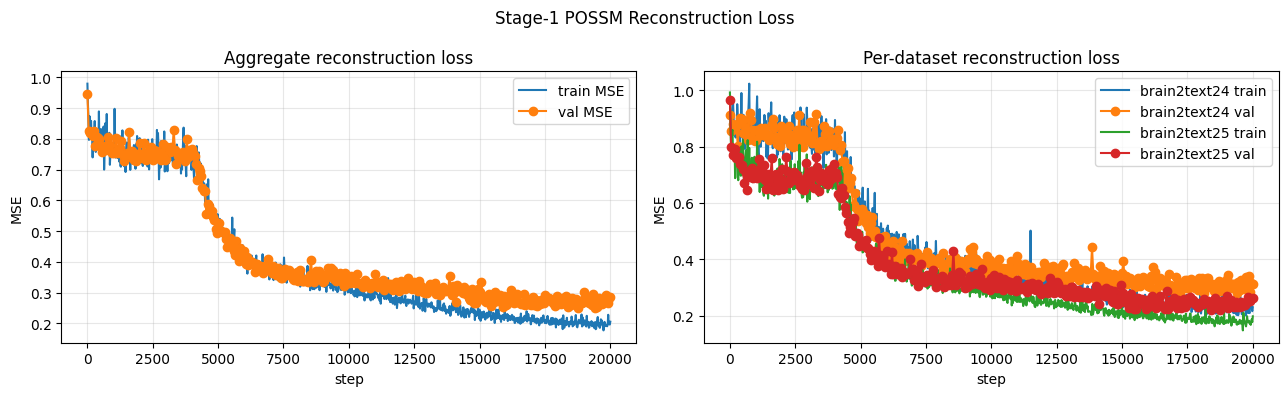

In [11]:
# Optional Stage-1 report / diagnostics.

STAGE1_REPORT = display_possm_stage1_report(STAGE1_RUN_STATE)
if RUN_STAGE1_PREDICTION_DIAGNOSTICS:
    STAGE1_PREDICTION_DIAGNOSTICS = run_possm_stage1_prediction_diagnostics(
        STAGE1_RUN_STATE,
        device=DEVICE,
    )


In [12]:
# Stage-2 config + checkpoint handoff.

if STAGE2_RUN_ACTION == 'recover_only':
    STAGE2_STAGE1_CHECKPOINT = None
    STAGE2_CHECKPOINT_SOURCE = 'unused for recover_only'
elif STAGE2_STAGE1_CHECKPOINT_OVERRIDE is not None:
    STAGE2_STAGE1_CHECKPOINT = Path(STAGE2_STAGE1_CHECKPOINT_OVERRIDE)
    STAGE2_CHECKPOINT_SOURCE = 'explicit override'
elif isinstance(globals().get('STAGE1_RUN_STATE'), dict) and 'best_checkpoint_path' in STAGE1_RUN_STATE:
    STAGE2_STAGE1_CHECKPOINT = Path(STAGE1_RUN_STATE['best_checkpoint_path'])
    STAGE2_CHECKPOINT_SOURCE = 'in-memory STAGE1_RUN_STATE best checkpoint'
elif STAGE1_RECOVERED_CHECKPOINT_PATH is not None:
    STAGE2_STAGE1_CHECKPOINT = Path(STAGE1_RECOVERED_CHECKPOINT_PATH)
    STAGE2_CHECKPOINT_SOURCE = 'explicit Stage-1 recovery checkpoint'
else:
    STAGE2_STAGE1_CHECKPOINT = resolve_possm_checkpoint_path(
        run_dir=STAGE1_OUTPUT_ROOT / STAGE1_RUN_NAME,
    )
    STAGE2_CHECKPOINT_SOURCE = 'named SBP-only Stage-1 run directory'

if STAGE2_STAGE1_CHECKPOINT is not None and not STAGE2_STAGE1_CHECKPOINT.exists():
    raise FileNotFoundError(f'Stage-1 checkpoint not found: {STAGE2_STAGE1_CHECKPOINT}')
if STAGE2_INIT_SOURCE not in {'stage1', 'random'}:
    raise ValueError("STAGE2_INIT_SOURCE must be one of {'stage1', 'random'}")

if STAGE2_INPUT_SOURCE == 'smoothed_cache':
    STAGE2_CACHE_ROOT = DEFAULT_CACHE_ROOT_SMOOTHED
    STAGE2_INPUT_SMOOTHING_SIGMA_BINS = 0.0
elif STAGE2_INPUT_SOURCE == 'raw_online_smoothing':
    STAGE2_CACHE_ROOT = DEFAULT_CACHE_ROOT_RAW
    STAGE2_INPUT_SMOOTHING_SIGMA_BINS = 2.0
else:
    raise ValueError("STAGE2_INPUT_SOURCE must be one of {'smoothed_cache', 'raw_online_smoothing'}")

if not STAGE2_CACHE_ROOT.exists():
    raise FileNotFoundError(f'Stage-2 cache root not found: {STAGE2_CACHE_ROOT}')

STAGE2_SPLIT_STATS_PATH = resolve_precomputed_split_stats_path(
    cache_root=STAGE2_CACHE_ROOT,
    dataset=DATASET,
    train_split_name='competition_train',
    signal_spec=STAGE1_SIGNAL_SPEC,
    preferred_path=None,
)
if not STAGE2_SPLIT_STATS_PATH.exists():
    raise FileNotFoundError(
        'Stage-2 split stats are missing. Run the canonical stats helper cell first: '
        f'{STAGE2_SPLIT_STATS_PATH}'
    )

if STAGE2_CONFIG_PRESET == 'historical_probe_frozen':
    stage2_config_payload = dict(
        mode='probe_frozen',
        weight_decay=1e-3,
        session_adapter_enabled=False,
    )
elif STAGE2_CONFIG_PRESET == 'current_finetune_full':
    stage2_config_payload = dict(
        mode='probe_frozen' if STAGE2_STATE_MODE == 'probe_frozen' else 'finetune_full',
        weight_decay=1e-3,
        session_adapter_enabled=STAGE2_SESSION_ADAPTER_ENABLED,
    )
else:
    raise ValueError("STAGE2_CONFIG_PRESET must be one of {'historical_probe_frozen', 'current_finetune_full'}")

STAGE2_CONFIG = POSSMFinetuneConfig(
    seed=SEED,
    precision=PRECISION,
    init_source=STAGE2_INIT_SOURCE,
    dataset=DATASET,
    signal_spec=STAGE1_SIGNAL_SPEC,
    data_mode=STAGE1_DATA_MODE,
    boundary_key_mode=BOUNDARY_KEY_MODE,
    batch_size=32,
    num_steps=STAGE2_SCREEN_NUM_STEPS,
    learning_rate=2e-4,
    encoder_learning_rate=3e-5,
    max_grad_norm=1.0,
    val_every_steps=STAGE2_SCREEN_VAL_EVERY_STEPS,
    checkpoint_every_steps=STAGE2_SCREEN_CHECKPOINT_EVERY_STEPS,
    checkpoint_keep_last=2,
    progress_every_steps=20,
    benchmark_warmup_steps=20,
    benchmark_measure_steps=100,
    input_smoothing_sigma_bins=STAGE2_INPUT_SMOOTHING_SIGMA_BINS,
    input_smoothing_kernel_size=100,
    input_smoothing_threshold=0.01,
    white_noise_sd=0.1,
    constant_offset_sd=0.05,
    precomputed_split_stats_path=STAGE2_SPLIT_STATS_PATH,
    decoder_backbone_type='gru',
    gru_hidden_size=768, gru_num_layers=5, gru_dropout=0.2,
    emission_mode=STAGE2_EMISSION_MODE,
    pre_decoder_patch_size=STAGE2_PRE_DECODER_PATCH_SIZE,
    pre_decoder_patch_stride=STAGE2_PRE_DECODER_PATCH_STRIDE,
    **stage2_config_payload,
)

print('STAGE2_RUN_ACTION:', STAGE2_RUN_ACTION)
print('STAGE2_CONFIG_PRESET:', STAGE2_CONFIG_PRESET)
print('STAGE2_INIT_SOURCE:', STAGE2_INIT_SOURCE)
print('STAGE2_INPUT_SOURCE:', STAGE2_INPUT_SOURCE)
print('STAGE2_EMISSION_MODE:', STAGE2_EMISSION_MODE)
print('STAGE2_PRE_DECODER_PATCH:', (STAGE2_PRE_DECODER_PATCH_SIZE, STAGE2_PRE_DECODER_PATCH_STRIDE))
print('STAGE2_CHECKPOINT_SOURCE:', STAGE2_CHECKPOINT_SOURCE)
print('STAGE2_STAGE1_CHECKPOINT:', STAGE2_STAGE1_CHECKPOINT)
print('STAGE2_CACHE_ROOT:', STAGE2_CACHE_ROOT)
print('STAGE2_SPLIT_STATS_PATH:', STAGE2_SPLIT_STATS_PATH)
print('STAGE2_INPUT_SMOOTHING_SIGMA_BINS:', STAGE2_INPUT_SMOOTHING_SIGMA_BINS)
print(STAGE2_CONFIG)


STAGE2_RUN_ACTION: fresh
STAGE2_CONFIG_PRESET: current_finetune_full
STAGE2_INIT_SOURCE: stage1
STAGE2_INPUT_SOURCE: raw_online_smoothing
STAGE2_EMISSION_MODE: post_decoder_conv
STAGE2_PRE_DECODER_PATCH: (14, 4)
STAGE2_CHECKPOINT_SOURCE: in-memory STAGE1_RUN_STATE best checkpoint
STAGE2_STAGE1_CHECKPOINT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/possm_masked_reconstruction/sbp_only_pooled_b2t24_b2t25_amp_fp16_20k_v1/possm_stage1_sbp_pooled_b2t24_b2t25_20k_seed7_amp_fp16_v1/checkpoint_best.pt
STAGE2_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1_sbpclip12500_fp16_raw
STAGE2_SPLIT_STATS_PATH: /content/drive/MyDrive/utah_ssl/data/stats/split_feature_stats/sbpclip12500_fp16_raw/brain2text24/competition_train/sbp_only/global_v1.pt
STAGE2_INPUT_SMOOTHING_SIGMA_BINS: 2.0
POSSMFinetuneConfig(seed=7, mode='finetune_full', init_source='stage1', dataset='brain2text24', split_policy='competition_train_test', signal_spec=SignalSpec(mode='sbp_only', tx_dim=0, sbp_dim=128, c

In [13]:
# Colab/PyTorch 2.6 compatibility for our trusted local checkpoints.
_ORIGINAL_TORCH_LOAD = getattr(torch, '_possm_original_torch_load', torch.serialization.load)
torch._possm_original_torch_load = _ORIGINAL_TORCH_LOAD

def _torch_load_weights_only_false(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _ORIGINAL_TORCH_LOAD(*args, **kwargs)

torch.load = _torch_load_weights_only_false

In [14]:
print("decoder:", STAGE2_CONFIG.decoder_backbone_type)
print("init_source:", STAGE2_CONFIG.init_source)
print("emission_mode:", STAGE2_CONFIG.emission_mode)
print("pre_decoder_patch:", (STAGE2_CONFIG.pre_decoder_patch_size, STAGE2_CONFIG.pre_decoder_patch_stride))


decoder: gru
init_source: stage1
emission_mode: post_decoder_conv
pre_decoder_patch: (14, 4)


In [15]:
# Stage-2 run, recover, or resume.

STAGE2_T0 = time.perf_counter()
STAGE2_OUTPUT_ROOT = OUTPUT_ROOT / STAGE2_OUTPUT_SUBDIR
STAGE2_SUMMARY = None
RECOVERED_STAGE2_SUMMARY = None

if STAGE2_RUN_ACTION == 'skip':
    print('Skipping stage-2.')
elif STAGE2_RUN_ACTION == 'fresh':
    STAGE2_SUMMARY = run_possm_phoneme_finetuning(
        checkpoint_path=STAGE2_STAGE1_CHECKPOINT,
        cache_root=STAGE2_CACHE_ROOT,
        output_root=STAGE2_OUTPUT_ROOT,
        config=STAGE2_CONFIG,
        device=DEVICE,
    )
elif STAGE2_RUN_ACTION in {'recover_only', 'resume_latest'}:
    RECOVERED_STAGE2_SUMMARY = recover_possm_stage2_summary(
        STAGE2_OUTPUT_ROOT,
        run_dir=STAGE2_RECOVERY_RUN_DIR_OVERRIDE,
        checkpoint_path=STAGE2_RECOVERY_CHECKPOINT_OVERRIDE,
    )
    print('recovered stage2 run_dir:', RECOVERED_STAGE2_SUMMARY['run_dir'])
    print('resume checkpoint:', RECOVERED_STAGE2_SUMMARY['resume_checkpoint_path'])
    if STAGE2_RUN_ACTION == 'recover_only':
        STAGE2_SUMMARY = RECOVERED_STAGE2_SUMMARY
    else:
        recovered_config_payload = dict(RECOVERED_STAGE2_SUMMARY['config'])
        recovered_step = int(RECOVERED_STAGE2_SUMMARY['steps'])
        if int(STAGE2_SCREEN_NUM_STEPS) < recovered_step:
            raise ValueError(
                f'Stage-2 target {STAGE2_SCREEN_NUM_STEPS} is behind recovered step {recovered_step}.'
            )
        recovered_config_payload['num_steps'] = int(STAGE2_SCREEN_NUM_STEPS)
        recovered_config = POSSMFinetuneConfig(**recovered_config_payload)
        print('Stage-2 resume target:', recovered_step, '->', recovered_config.num_steps)
        STAGE2_SUMMARY = run_possm_phoneme_finetuning(
            checkpoint_path=RECOVERED_STAGE2_SUMMARY['stage1_checkpoint_path'],
            cache_root=RECOVERED_STAGE2_SUMMARY['cache_root'],
            output_root=STAGE2_OUTPUT_ROOT,
            config=recovered_config,
            device=DEVICE,
            run_name=RECOVERED_STAGE2_SUMMARY['run_name'],
            resume_from_latest=True,
        )
else:
    raise ValueError("STAGE2_RUN_ACTION must be one of {'fresh', 'resume_latest', 'recover_only', 'skip'}")

if STAGE2_SUMMARY is not None:
    print('stage2 run_dir:', STAGE2_SUMMARY['run_dir'])
    print('stage2 requested/resolved precision:', STAGE2_SUMMARY.get('requested_precision'), STAGE2_SUMMARY.get('resolved_precision'))
    print('stage2 AMP/scaler:', STAGE2_SUMMARY.get('amp_enabled'), STAGE2_SUMMARY.get('grad_scaler_enabled'))
    print('stage2 optimizer fused:', STAGE2_SUMMARY.get('optimizer_fused'))
    print('stage2 resumed_from_checkpoint:', STAGE2_SUMMARY.get('resumed_from_checkpoint'))
    print('stage2 best checkpoint:', STAGE2_SUMMARY.get('checkpoint_best_path'))
    print('stage2 final checkpoint:', STAGE2_SUMMARY.get('checkpoint_final_path'))
print('stage2 elapsed_s:', round(time.perf_counter() - STAGE2_T0, 1))


loaded precomputed POSSM stage-2 split stats: /content/drive/MyDrive/utah_ssl/data/stats/split_feature_stats/sbpclip12500_fp16_raw/brain2text24/competition_train/sbp_only/global_v1.pt
[stage2 train] step=1 train_ctc_bpphone=11.861 sample_s=96.39 model_s=2.27 elapsed_s=98.6
[stage2 train] step=20 train_ctc_bpphone=4.808 sample_s=0.02 model_s=1.14 elapsed_s=126.6
[stage2 train] step=40 train_ctc_bpphone=4.720 sample_s=0.01 model_s=0.51 elapsed_s=147.3
[stage2 train] step=60 train_ctc_bpphone=4.658 sample_s=0.02 model_s=0.86 elapsed_s=167.3
[stage2 train] step=80 train_ctc_bpphone=4.665 sample_s=0.02 model_s=1.14 elapsed_s=186.6
[stage2 train] step=100 train_ctc_bpphone=4.644 sample_s=0.02 model_s=1.16 elapsed_s=204.5
[stage2 train] step=120 train_ctc_bpphone=4.554 sample_s=0.01 model_s=0.50 elapsed_s=222.7
[stage2 train] step=140 train_ctc_bpphone=4.496 sample_s=0.02 model_s=0.91 elapsed_s=239.8
[stage2 train] step=160 train_ctc_bpphone=4.514 sample_s=0.02 model_s=0.56 elapsed_s=255.1
[s

,event,stage,step,elapsed_seconds,train_ctc_bpphone,microbatch_examples,accumulation_microbatches,optimizer_target_examples,effective_examples_per_step,sample_seconds,...,measured_steps,measured_examples,measured_seconds,blank_frame_rate,predicted_to_reference_token_ratio,val_ctc_bpphone,val_phoneme_error_rate,collapse_diagnostics,model_num_parameters,encoder_num_parameters
711,phoneme_train_report,possm_phoneme_finetune,11860,7159.723,0.904230,41.0,2.0,32.0,41.0,0.0191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
712,phoneme_train_report,possm_phoneme_finetune,11880,7170.335,0.904471,40.0,2.0,32.0,40.0,0.0184,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
713,phoneme_train_report,possm_phoneme_finetune,11900,7180.944,0.492346,32.0,1.0,32.0,32.0,0.0126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
714,phoneme_val_report,possm_phoneme_finetune,11900,7184.159,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.514062,0.894935,2.364707,0.390208,"{'total_reference_tokens': 24223, 'total_predi...",25397545.0,569600.0
715,phoneme_train_report,possm_phoneme_finetune,11920,7194.250,0.743380,32.0,1.0,32.0,32.0,0.0143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
716,phoneme_train_report,possm_phoneme_finetune,11940,7205.709,0.864532,32.0,1.0,32.0,32.0,0.0145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
717,phoneme_train_report,possm_phoneme_finetune,11960,7216.860,0.745197,32.0,1.0,32.0,32.0,0.0129,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
718,phoneme_train_report,possm_phoneme_finetune,11980,7228.064,0.906358,40.0,2.0,32.0,40.0,0.0193,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719,phoneme_train_report,possm_phoneme_finetune,12000,7237.999,1.025990,50.0,2.0,32.0,50.0,0.0235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
720,phoneme_val_report,possm_phoneme_finetune,12000,7241.216,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.547269,0.860752,2.739753,0.435247,"{'total_reference_tokens': 24223, 'total_predi...",25397545.0,569600.0


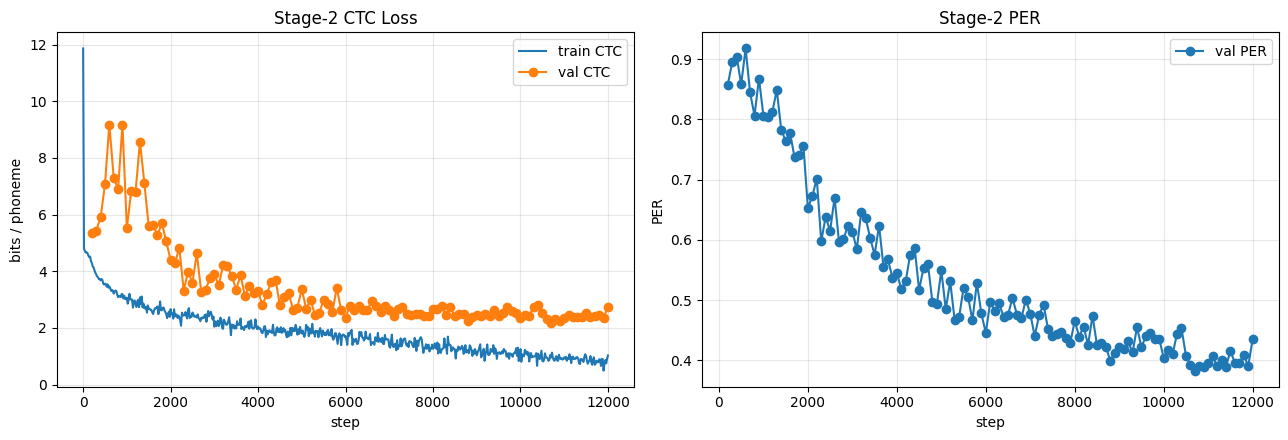

,run_name,mode,decoder_backbone_type,s5_direction,steps,val_ctc_bpphone,val_phoneme_error_rate,best_val_ctc_bpphone,best_val_phoneme_error_rate,resume_checkpoint_path,checkpoint_best_path,checkpoint_final_path
0,possm_stage2_finetune_full_sbp_only_20260804T1...,finetune_full,gru,causal,12000,2.739753,0.435247,2.171483,0.382983,None,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...


,blank_frame_rate,predicted_to_reference_token_ratio,total_predicted_tokens,total_reference_tokens,prediction_top_ids,reference_top_ids
0,0.547269,0.860752,20850,24223,"[[40, 5421], [31, 1332], [17, 1204], [3, 1135]...","[[40, 5498], [3, 1621], [31, 1585], [23, 1224]..."


notebook elapsed_s: 9194.4


In [16]:
# Optional Stage-2 report / diagnostics.

STAGE2_REPORT = display_possm_stage2_report(STAGE2_SUMMARY)
STAGE2_SUMMARY_FRAMES = display_possm_stage2_summary(STAGE2_SUMMARY)
if RUN_STAGE2_PREDICTION_DIAGNOSTICS and STAGE2_SUMMARY is not None:
    STAGE2_PREDICTION_DIAGNOSTICS = run_possm_stage2_prediction_diagnostics(
        STAGE2_SUMMARY,
        device=DEVICE,
    )
print('notebook elapsed_s:', round(time.perf_counter() - NOTEBOOK_T0, 1))


In [17]:
from google.colab import runtime
runtime.unassign()